# Re-ranking con diversidad, novedad y clickbait score

Este notebook corresponde a la segunda etapa del proyecto **Multimodalidad: recomendación de noticias**. Su objetivo es construir y evaluar una primera solución que use las features creadas en el notebook `FeatureEngineering_MIND.ipynb` para modificar el ranking base de noticias.

En este notebook se toma como punto de partida el modelo **TF-IDF basado en contenido**, que recomienda noticias según la similitud entre el historial del usuario y las noticias candidatas. Luego, sobre ese ranking base, se aplican ajustes mediante re-ranking para incorporar criterios adicionales alineados con los objetivos del proyecto: **diversidad**, **novedad** y **reducción de clickbait**.

El flujo general del notebook es el siguiente:

1. **Carga de datos**
   Se cargan los archivos de MIND Small correspondientes a noticias (`news.tsv`) y comportamientos de usuarios (`behaviors.tsv`) tanto para train como para dev. También se carga el archivo `news_features_light_all.csv`, generado previamente, que contiene features enriquecidas por noticia.

2. **Construcción de representación TF-IDF**
   Cada noticia se representa usando el texto compuesto por su título y resumen. A partir de esto se construye una matriz TF-IDF, que permite calcular similitud textual entre noticias.

3. **Perfil de usuario**
   Para cada impresión de validación, se construye un perfil del usuario como el promedio de las representaciones TF-IDF de las noticias presentes en su historial de lectura.

4. **Ranking base**
   Para cada usuario e impresión, se calcula un `score_tfidf` para cada noticia candidata. Este score mide qué tan similar es la noticia candidata al historial del usuario. Este ranking funciona como modelo base de contenido.

5. **Integración de features nuevas**
   El ranking base se une con las features creadas anteriormente, incluyendo:
   - `clickbait_score`: score experimental entre 0 y 1 que aproxima la presencia de señales de clickbait en el título y su discrepancia con el abstract.
   - `novelty_score_norm`: medida de novedad basada en popularidad histórica.
   - `category` y `subcategory`: usadas para medir diversidad temática.
   - `high_clickbait_synthetic`: etiqueta sintética creada en este notebook para identificar noticias con clickbait alto según el score.

6. **Creación de variantes del modelo**
   Se comparan distintas versiones del ranking:
   - `TF-IDF base`: solo usa similitud textual.
   - `TF-IDF + low clickbait`: favorece noticias con menor `clickbait_score`.
   - `TF-IDF + novelty`: incorpora novedad.
   - `TF-IDF + low clickbait + novelty`: combina menor clickbait y novedad.
   - `Re-ranking completo`: además de menor clickbait y novedad, aplica una penalización por redundancia de categoría para favorecer diversidad temática en el top-10.

7. **Evaluación**
   Los modelos se evalúan con métricas tradicionales de ranking:
   - AUC
   - MRR@10
   - NDCG@10

   Y también con métricas alineadas con los objetivos del proyecto:
   - `CategoryCoverage@10`: cantidad promedio de categorías distintas en el top-10.
   - `CategoryDiversity@10`: diversidad categórica entre las noticias recomendadas.
   - `Novelty@10`: novedad promedio del top-10.
   - `ClickbaitScore@10`: clickbait promedio del top-10. En esta métrica, menor es mejor.
   - `HighClickbaitRate@10`: proporción de noticias con clickbait alto en el top-10. En esta métrica, menor es mejor.

8. **Análisis del trade-off**
   El objetivo no es solo maximizar clicks, sino estudiar cómo cambia el ranking al incorporar criterios informativos. Por eso, se analiza el posible trade-off entre métricas tradicionales de precisión, como NDCG o MRR, y métricas relacionadas con diversidad, novedad y reducción de clickbait.

Es importante destacar que `clickbait_score` no representa factualidad real de las noticias, ya que MIND no contiene labels de fake news. Esta variable debe interpretarse como una señal experimental de estilo informativo/sensacionalista usada para estudiar el comportamiento del re-ranking, no como un detector real de noticias falsas.


In [ ]:
from google.colab import drive

from tqdm.notebook import tqdm
import time

from pathlib import Path
import zipfile
import json
import ast
import re
import math
import numpy as np
import pandas as pd

drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/Proyecto")

EXTRACT_DIR = PROJECT_DIR / "mindsmall_extracted"
TRAIN_DIR = EXTRACT_DIR / "train"
DEV_DIR = EXTRACT_DIR / "dev"

FEATURES_PATH = PROJECT_DIR / "news_features_light_all.csv"

print("Existe Proyecto:", PROJECT_DIR.exists())
print("Existe train:", TRAIN_DIR.exists())
print("Existe dev:", DEV_DIR.exists())
print("Existe news_features_light:", FEATURES_PATH.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Existe Proyecto: True
Existe train: True
Existe dev: True
Existe news_features_light: True


In [ ]:
def find_file(base_dir, filename):
    matches = list(base_dir.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"No encontré {filename} dentro de {base_dir}")
    return matches[0]

train_news_path = find_file(TRAIN_DIR, "news.tsv")
train_behaviors_path = find_file(TRAIN_DIR, "behaviors.tsv")

dev_news_path = find_file(DEV_DIR, "news.tsv")
dev_behaviors_path = find_file(DEV_DIR, "behaviors.tsv")

print("Train news:", train_news_path)
print("Train behaviors:", train_behaviors_path)
print("Dev news:", dev_news_path)
print("Dev behaviors:", dev_behaviors_path)

Train news: /content/drive/MyDrive/Proyecto/mindsmall_extracted/train/MINDsmall_train/news.tsv
Train behaviors: /content/drive/MyDrive/Proyecto/mindsmall_extracted/train/MINDsmall_train/behaviors.tsv
Dev news: /content/drive/MyDrive/Proyecto/mindsmall_extracted/dev/MINDsmall_dev/news.tsv
Dev behaviors: /content/drive/MyDrive/Proyecto/mindsmall_extracted/dev/MINDsmall_dev/behaviors.tsv


Cargar noticias, behaviors y features

In [ ]:
news_cols = [
    "news_id",
    "category",
    "subcategory",
    "title",
    "abstract",
    "url",
    "title_entities",
    "abstract_entities"
]

train_news = pd.read_csv(
    train_news_path,
    sep="\t",
    header=None,
    names=news_cols,
    quoting=3
)

dev_news = pd.read_csv(
    dev_news_path,
    sep="\t",
    header=None,
    names=news_cols,
    quoting=3
)

behaviors_cols = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

train_behaviors = pd.read_csv(
    train_behaviors_path,
    sep="\t",
    header=None,
    names=behaviors_cols
)

dev_behaviors = pd.read_csv(
    dev_behaviors_path,
    sep="\t",
    header=None,
    names=behaviors_cols
)

features = pd.read_csv(FEATURES_PATH)

print("train_news:", train_news.shape)
print("dev_news:", dev_news.shape)
print("train_behaviors:", train_behaviors.shape)
print("dev_behaviors:", dev_behaviors.shape)
print("features:", features.shape)

features.head()

train_news: (51282, 8)
dev_news: (42416, 8)
train_behaviors: (156965, 5)
dev_behaviors: (73152, 5)
features: (65238, 21)


,news_id,category,subcategory,title,title_length,abstract_length,num_words_title,num_words_abstract,has_abstract,num_title_entities,...,num_total_entities,entity_confidence_avg,impressions_count,clicks_count,ctr,popularity_score,novelty_score_norm,clickbait_score,veracity_proxy,low_veracity_synthetic
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...",70,73,11,12,1,3,...,3,0.99000,0,0,0.0,0.000000,1.000000,0.250000,0.690500,0
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,29,116,6,19,1,1,...,1,1.00000,0,0,0.0,0.000000,1.000000,0.130886,0.690367,0
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,63,196,12,36,1,0,...,1,0.94600,0,0,0.0,0.000000,1.000000,0.223696,0.665646,1
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,59,99,12,21,1,0,...,1,1.00000,0,0,0.0,0.000000,1.000000,0.185266,0.682210,0
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...",57,179,11,31,1,1,...,3,0.99975,1,0,0.0,0.000043,0.930995,0.087169,0.716875,0


##Preparar texto para TF-IDF

Usaremos título + abstract para representar cada noticia.

In [ ]:
# Usamos train + dev para poder representar también las noticias candidatas de dev
news_df = pd.concat([train_news, dev_news], ignore_index=True)
news_df = news_df.drop_duplicates(subset="news_id", keep="first").reset_index(drop=True)

for col in ["title", "abstract", "category", "subcategory"]:
    news_df[col] = news_df[col].fillna("")

news_df["text"] = news_df["title"].astype(str) + " " + news_df["abstract"].astype(str)

news_df[["news_id", "title", "abstract", "text"]].head()

,news_id,title,abstract,text
0,N55528,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...","The Brands Queen Elizabeth, Prince Charles, an..."
1,N19639,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,50 Worst Habits For Belly Fat These seemingly ...
2,N61837,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,The Cost of Trump's Aid Freeze in the Trenches...
3,N53526,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",I Was An NBA Wife. Here's How It Affected My M...
4,N38324,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...","How to Get Rid of Skin Tags, According to a De..."


## Crear matriz TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

tfidf = TfidfVectorizer(
    max_features=50000,
    stop_words="english",
    min_df=2
)

news_tfidf = tfidf.fit_transform(news_df["text"])

# Normalizamos para que el producto punto sea similitud coseno
news_tfidf = normalize(news_tfidf)

news_id_to_idx = {
    news_id: idx for idx, news_id in enumerate(news_df["news_id"])
}

print("Matriz TF-IDF:", news_tfidf.shape)

Matriz TF-IDF: (65238, 36502)


## Funciones para parsear historial e impresiones

In [ ]:
def parse_history(history_str):
    if pd.isna(history_str) or str(history_str).strip() == "":
        return []
    return str(history_str).split()

def parse_impressions(impression_str):
    """
    Convierte:
    N123-0 N456-1 N789-0
    en:
    [(N123, 0), (N456, 1), (N789, 0)]
    """
    if pd.isna(impression_str):
        return []

    pairs = []
    for item in str(impression_str).split():
        if "-" not in item:
            continue
        news_id, clicked = item.rsplit("-", 1)
        try:
            clicked = int(clicked)
        except:
            clicked = 0
        pairs.append((news_id, clicked))
    return pairs

##Crear perfil TF-IDF de usuario

Para cada impresión, el perfil del usuario será el promedio TF-IDF de las noticias de su historial.

In [ ]:
from scipy.sparse import csr_matrix

def get_user_profile(history_news_ids):
    valid_indices = [
        news_id_to_idx[nid]
        for nid in history_news_ids
        if nid in news_id_to_idx
    ]

    if len(valid_indices) == 0:
        return None

    profile = news_tfidf[valid_indices].mean(axis=0)
    profile = csr_matrix(profile)
    profile = normalize(profile)
    return profile

#Crear ranking TF-IDF base

In [ ]:
EVAL_LIMIT = 5000  # para probar rápido. Luego usar None para todo.

if EVAL_LIMIT is None:
    dev_eval = dev_behaviors.copy()
else:
    dev_eval = dev_behaviors.head(EVAL_LIMIT).copy()

print("Impresiones a evaluar:", len(dev_eval))

Impresiones a evaluar: 5000


In [ ]:
def score_candidates_tfidf(history_news_ids, candidate_news_ids):
    profile = get_user_profile(history_news_ids)

    # Si el usuario no tiene historial, dejamos score 0 para todos
    if profile is None:
        return np.zeros(len(candidate_news_ids))

    scores = []
    for nid in candidate_news_ids:
        if nid in news_id_to_idx:
            idx = news_id_to_idx[nid]
            score = profile.dot(news_tfidf[idx].T).toarray()[0, 0]
        else:
            score = 0.0
        scores.append(score)

    return np.array(scores)

In [ ]:
rows = []

start_time = time.time()

for _, row in tqdm(dev_eval.iterrows(), total=len(dev_eval), desc="Construyendo ranking TF-IDF"):
    impression_id = row["impression_id"]
    user_id = row["user_id"]
    history_ids = parse_history(row["history"])
    candidates = parse_impressions(row["impressions"])

    candidate_ids = [nid for nid, label in candidates]
    labels = [label for nid, label in candidates]

    tfidf_scores = score_candidates_tfidf(history_ids, candidate_ids)

    for nid, label, score in zip(candidate_ids, labels, tfidf_scores):
        rows.append({
            "impression_id": impression_id,
            "user_id": user_id,
            "news_id": nid,
            "label": label,
            "score_tfidf": score
        })

ranking_df = pd.DataFrame(rows)

elapsed = time.time() - start_time
print(f"Tiempo total: {elapsed/60:.2f} minutos")
print(ranking_df.shape)
ranking_df.head()

Construyendo ranking TF-IDF:   0%|          | 0/5000 [00:00<?, ?it/s]

Tiempo total: 1.16 minutos
(187009, 5)


,impression_id,user_id,news_id,label,score_tfidf
0,1,U80234,N28682,0,0.012624
1,1,U80234,N48740,0,0.030173
2,1,U80234,N31958,1,0.019648
3,1,U80234,N34130,0,0.005106
4,1,U80234,N6916,0,0.013366


# Unir ranking con features nuevas

In [ ]:
if "clickbait_score" not in features.columns:
    raise KeyError(
        "No se encontró la columna 'clickbait_score' en news_features_light_all.csv. "
        "Vuelve a correr el notebook de Feature Engineering con el cálculo de clickbait_score."
    )

ranking_df = ranking_df.merge(
    features,
    on="news_id",
    how="left"
)

# Rellenamos features faltantes, por si aparece alguna noticia dev que no estaba en train features.
# Para clickbait_score usamos el promedio de features, para no premiar ni castigar noticias desconocidas.
fill_values = {
    "clickbait_score": features["clickbait_score"].mean(),
    "novelty_score_norm": features["novelty_score_norm"].mean(),
    "popularity_score": 0.0,
    "category": "unknown",
    "subcategory": "unknown",
    "num_total_entities": 0
}

for col, value in fill_values.items():
    if col in ranking_df.columns:
        ranking_df[col] = ranking_df[col].fillna(value)

print(ranking_df.shape)
ranking_df[[
    "impression_id",
    "news_id",
    "label",
    "score_tfidf",
    "clickbait_score",
    "novelty_score_norm",
    "category"
]].head()


(187009, 25)


,impression_id,news_id,label,score_tfidf,clickbait_score,novelty_score_norm,category
0,1,N28682,0,0.012624,0.230265,1.000000,sports
1,1,N48740,0,0.030173,0.218005,0.930995,lifestyle
2,1,N31958,1,0.019648,0.172098,0.890630,sports
3,1,N34130,0,0.005106,0.122268,0.890630,tv
4,1,N6916,0,0.013366,0.250000,0.306324,entertainment


# Normalizar scores dentro de cada impresión

Esto es importante porque `score_tfidf`, `clickbait_score` y `novelty_score_norm` pueden estar en escalas distintas. Como un mayor `clickbait_score` es peor, después de normalizarlo creamos `score_low_clickbait_norm = 1 - clickbait_score_norm`, que sí se puede sumar al score del ranking.


In [ ]:
def minmax_by_group(df, group_col, value_col, new_col):
    def scale(s):
        min_val = s.min()
        max_val = s.max()
        if max_val > min_val:
            return (s - min_val) / (max_val - min_val)
        else:
            return pd.Series(0.0, index=s.index)

    df[new_col] = df.groupby(group_col)[value_col].transform(scale)
    return df

# Baseline Random
np.random.seed(42)
ranking_df["score_random"] = np.random.rand(len(ranking_df))

# Baseline Most Popular basado en popularidad histórica de train
ranking_df = minmax_by_group(
    ranking_df,
    "impression_id",
    "popularity_score",
    "score_popularity_norm"
)

ranking_df = minmax_by_group(ranking_df, "impression_id", "score_tfidf", "score_tfidf_norm")
ranking_df = minmax_by_group(ranking_df, "impression_id", "clickbait_score", "clickbait_score_norm")
ranking_df = minmax_by_group(ranking_df, "impression_id", "novelty_score_norm", "novelty_score_norm_imp")

# Como un clickbait_score alto es indeseable, usamos este score invertido para el ranking.
ranking_df["score_low_clickbait_norm"] = 1.0 - ranking_df["clickbait_score_norm"]

# Etiqueta sintética de clickbait alto para evaluar proporción en el top-k.
# Si todos los scores son 0, no marcamos ninguna noticia como alta en clickbait.
clickbait_threshold = ranking_df["clickbait_score"].quantile(0.80)
ranking_df["high_clickbait_synthetic"] = (
    (ranking_df["clickbait_score"] >= clickbait_threshold) &
    (ranking_df["clickbait_score"] > 0)
).astype(int)

ranking_df[[
    "impression_id",
    "news_id",
    "label",
    "score_tfidf_norm",
    "clickbait_score",
    "clickbait_score_norm",
    "score_low_clickbait_norm",
    "novelty_score_norm_imp",
    "high_clickbait_synthetic"
]].head()


,impression_id,news_id,label,score_tfidf_norm,clickbait_score,clickbait_score_norm,score_low_clickbait_norm,novelty_score_norm_imp,high_clickbait_synthetic
0,1,N28682,0,0.418400,0.230265,0.742026,0.257974,1.000000,0
1,1,N48740,0,1.000000,0.218005,0.702518,0.297482,0.900523,0
2,1,N31958,1,0.651189,0.172098,0.554582,0.445418,0.842333,0
3,1,N34130,0,0.169239,0.122268,0.394005,0.605995,0.842333,0
4,1,N6916,0,0.442971,0.250000,0.805620,0.194380,0.000000,1


#Crear modelos de score simple

Primero creamos variantes sin diversidad secuencial.

In [ ]:
ranking_df["score_tfidf_only"] = ranking_df["score_tfidf_norm"]

ranking_df["score_tfidf_clickbait"] = (
    ranking_df["score_tfidf_norm"]
    + 0.10 * ranking_df["score_low_clickbait_norm"]
)

ranking_df["score_tfidf_novelty"] = (
    ranking_df["score_tfidf_norm"]
    + 0.05 * ranking_df["novelty_score_norm_imp"]
)

ranking_df["score_tfidf_clickbait_novelty"] = (
    ranking_df["score_tfidf_norm"]
    + 0.10 * ranking_df["score_low_clickbait_norm"]
    + 0.05 * ranking_df["novelty_score_norm_imp"]
)


#Re-ranking con diversidad de categoría

Este es el primer modelo “nuevo” más defendible.

La lógica es:

1. Ordenar candidatos por score base.
2. Elegir el mejor.
3. Para los siguientes, penalizar si la categoría ya fue elegida.
4. Repetir hasta ordenar toda la impresión.

In [ ]:
def diversity_rerank_group(
    group,
    base_score_col="score_tfidf_clickbait_novelty",
    delta_category=0.15
):
    group = group.copy()

    remaining = group.index.tolist()
    selected = []
    selected_categories = set()

    while remaining:
        best_idx = None
        best_score = -np.inf

        for idx in remaining:
            row = group.loc[idx]
            score = row[base_score_col]

            category = row["category"]
            redundancy_penalty = delta_category if category in selected_categories else 0.0

            adjusted_score = score - redundancy_penalty

            if adjusted_score > best_score:
                best_score = adjusted_score
                best_idx = idx

        selected.append(best_idx)
        selected_categories.add(group.loc[best_idx, "category"])
        remaining.remove(best_idx)

    group["score_rerank_diversity"] = 0.0

    # Asignamos score decreciente según el nuevo orden.
    # Lo importante es que preserve el ranking generado por el algoritmo.
    n = len(selected)
    for rank, idx in enumerate(selected):
        group.loc[idx, "score_rerank_diversity"] = n - rank

    return group


In [ ]:
ranking_df = (
    ranking_df
    .groupby("impression_id", group_keys=False)
    .apply(
        diversity_rerank_group,
        base_score_col="score_tfidf_clickbait_novelty",
        delta_category=0.15
    )
)

ranking_df[[
    "impression_id",
    "news_id",
    "label",
    "category",
    "score_tfidf_norm",
    "score_tfidf_clickbait_novelty",
    "score_rerank_diversity"
]].head()


/tmp/ipykernel_26829/713126562.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,impression_id,news_id,label,category,score_tfidf_norm,score_tfidf_clickbait_novelty,score_rerank_diversity
0,1,N28682,0,sports,0.418400,0.494197,12.0
1,1,N48740,0,lifestyle,1.000000,1.074774,22.0
2,1,N31958,1,sports,0.651189,0.737847,19.0
3,1,N34130,0,tv,0.169239,0.271955,6.0
4,1,N6916,0,entertainment,0.442971,0.462409,14.0


#Métricas de ranking

In [ ]:
from sklearn.metrics import roc_auc_score

def mrr_at_k(labels, scores, k=10):
    order = np.argsort(scores)[::-1]
    labels_sorted = np.array(labels)[order][:k]

    for i, rel in enumerate(labels_sorted, start=1):
        if rel == 1:
            return 1.0 / i
    return 0.0

def dcg_at_k(labels, scores, k=10):
    order = np.argsort(scores)[::-1]
    labels_sorted = np.array(labels)[order][:k]

    dcg = 0.0
    for i, rel in enumerate(labels_sorted, start=1):
        dcg += rel / np.log2(i + 1)
    return dcg

def ndcg_at_k(labels, scores, k=10):
    dcg = dcg_at_k(labels, scores, k)

    ideal_scores = np.array(labels)
    ideal_order = np.argsort(ideal_scores)[::-1]
    ideal_labels = np.array(labels)[ideal_order][:k]

    idcg = 0.0
    for i, rel in enumerate(ideal_labels, start=1):
        idcg += rel / np.log2(i + 1)

    if idcg == 0:
        return 0.0

    return dcg / idcg

# Métricas de novedad, diversidad y clickbait


In [ ]:
def category_coverage_at_k(group, score_col, k=10):
    topk = group.sort_values(score_col, ascending=False).head(k)
    return topk["category"].nunique()

def intra_list_category_diversity_at_k(group, score_col, k=10):
    """
    Diversidad simple por categoría.
    0 = todas las noticias del top-k tienen la misma categoría.
    1 = todas las noticias son de categorías distintas.
    """
    topk = group.sort_values(score_col, ascending=False).head(k)

    cats = topk["category"].tolist()
    n = len(cats)

    if n <= 1:
        return 0.0

    total_pairs = 0
    different_pairs = 0

    for i in range(n):
        for j in range(i + 1, n):
            total_pairs += 1
            if cats[i] != cats[j]:
                different_pairs += 1

    return different_pairs / total_pairs if total_pairs > 0 else 0.0

def mean_novelty_at_k(group, score_col, k=10):
    topk = group.sort_values(score_col, ascending=False).head(k)
    return topk["novelty_score_norm"].mean()

def mean_clickbait_at_k(group, score_col, k=10):
    topk = group.sort_values(score_col, ascending=False).head(k)
    return topk["clickbait_score"].mean()

def high_clickbait_rate_at_k(group, score_col, k=10):
    topk = group.sort_values(score_col, ascending=False).head(k)
    return topk["high_clickbait_synthetic"].mean()


#Evaluar un modelo

In [ ]:
def evaluate_model(ranking_df, score_col, k=10):
    aucs = []
    mrrs = []
    ndcgs = []
    coverages = []
    diversities = []
    novelties = []
    clickbait_scores = []
    high_clickbait_rates = []

    for impression_id, group in ranking_df.groupby("impression_id"):
        labels = group["label"].values
        scores = group[score_col].values

        # AUC solo se puede calcular si hay al menos un 0 y un 1
        if len(np.unique(labels)) > 1:
            try:
                aucs.append(roc_auc_score(labels, scores))
            except:
                pass

        mrrs.append(mrr_at_k(labels, scores, k=k))
        ndcgs.append(ndcg_at_k(labels, scores, k=k))

        coverages.append(category_coverage_at_k(group, score_col, k=k))
        diversities.append(intra_list_category_diversity_at_k(group, score_col, k=k))
        novelties.append(mean_novelty_at_k(group, score_col, k=k))
        clickbait_scores.append(mean_clickbait_at_k(group, score_col, k=k))
        high_clickbait_rates.append(high_clickbait_rate_at_k(group, score_col, k=k))

    return {
        "AUC": np.mean(aucs) if len(aucs) > 0 else np.nan,
        f"MRR@{k}": np.mean(mrrs),
        f"NDCG@{k}": np.mean(ndcgs),
        f"CategoryCoverage@{k}": np.mean(coverages),
        f"CategoryDiversity@{k}": np.mean(diversities),
        f"Novelty@{k}": np.mean(novelties),
        f"ClickbaitScore@{k}": np.mean(clickbait_scores),
        f"HighClickbaitRate@{k}": np.mean(high_clickbait_rates)
    }


#COmparar modelos

In [ ]:
models_to_evaluate = {
    "Random": "score_random",
    "Most Popular": "score_popularity_norm",
    "TF-IDF base": "score_tfidf_only",
    "TF-IDF + low clickbait": "score_tfidf_clickbait",
    "TF-IDF + novelty": "score_tfidf_novelty",
    "TF-IDF + low clickbait + novelty": "score_tfidf_clickbait_novelty",
    "Re-ranking completo": "score_rerank_diversity"
}

results = []

for model_name, score_col in models_to_evaluate.items():
    metrics = evaluate_model(ranking_df, score_col, k=10)
    metrics["model"] = model_name
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df[
    ["model"] + [col for col in results_df.columns if col != "model"]
]

results_df


,model,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10
0,Random,0.498667,0.227532,0.286858,5.8646,0.875441,0.728455,0.180448,0.184976
1,Most Popular,0.497540,0.225949,0.287941,5.9806,0.885298,0.505433,0.188002,0.248936
2,TF-IDF base,0.580933,0.309069,0.362479,5.3120,0.828712,0.718160,0.182331,0.171596
3,TF-IDF + low clickbait,0.586844,0.309470,0.362736,5.2762,0.825698,0.721833,0.173222,0.146336
4,TF-IDF + novelty,0.578257,0.306160,0.358638,5.2962,0.826756,0.739397,0.181954,0.164256
5,TF-IDF + low clickbait + novelty,0.585935,0.309567,0.362321,5.2676,0.824512,0.737987,0.173303,0.143376
6,Re-ranking completo,0.573185,0.304285,0.355068,6.4160,0.881592,0.735391,0.175763,0.154096


#Guardar resultados

In [ ]:
output_results_path = PROJECT_DIR / "reranking_results.csv"
results_df.to_csv(output_results_path, index=False)

print("Resultados guardados en:", output_results_path)
results_df

Resultados guardados en: /content/drive/MyDrive/Proyecto/reranking_results.csv


,model,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10
0,Random,0.498667,0.227532,0.286858,5.8646,0.875441,0.728455,0.180448,0.184976
1,Most Popular,0.497540,0.225949,0.287941,5.9806,0.885298,0.505433,0.188002,0.248936
2,TF-IDF base,0.580933,0.309069,0.362479,5.3120,0.828712,0.718160,0.182331,0.171596
3,TF-IDF + low clickbait,0.586844,0.309470,0.362736,5.2762,0.825698,0.721833,0.173222,0.146336
4,TF-IDF + novelty,0.578257,0.306160,0.358638,5.2962,0.826756,0.739397,0.181954,0.164256
5,TF-IDF + low clickbait + novelty,0.585935,0.309567,0.362321,5.2676,0.824512,0.737987,0.173303,0.143376
6,Re-ranking completo,0.573185,0.304285,0.355068,6.4160,0.881592,0.735391,0.175763,0.154096


#Ver ejemplos de una impresión

Esto sirve para inspeccionar si el re-ranking realmente cambia el orden.

In [ ]:
example_impression = ranking_df["impression_id"].iloc[0]

example = ranking_df[ranking_df["impression_id"] == example_impression].copy()

print("Impression ID:", example_impression)
print("Cantidad candidatos:", len(example))
print("Clicks reales:", example["label"].sum())

Impression ID: 1
Cantidad candidatos: 22
Clicks reales: 1


Ranking TF-IDF base

In [ ]:
example[[
    "news_id",
    "title",
    "category",
    "label",
    "score_tfidf_only",
    "clickbait_score",
    "novelty_score_norm",
    "high_clickbait_synthetic"
]].sort_values("score_tfidf_only", ascending=False).head(10)


,news_id,title,category,label,score_tfidf_only,clickbait_score,novelty_score_norm,high_clickbait_synthetic
1,N48740,I've been writing about tiny homes for a year ...,lifestyle,0,1.000000,0.218005,0.930995,0
14,N42844,Survivor Contestants Missy Byrd and Elizabeth ...,tv,0,0.761557,0.104045,0.781260,0
10,N62365,The Unlikely Star of My Family's Thanksgiving ...,foodanddrink,0,0.691739,0.232380,0.930995,0
2,N31958,Opinion: Colin Kaepernick is about to get what...,sports,1,0.651189,0.172098,0.890630,0
6,N50775,"U.S. Troops Will Die If They Remain in Syria, ...",news,0,0.612516,0.226004,0.930995,0
9,N33176,Surviving Santa Clarita school shooting victim...,news,0,0.593070,0.185622,1.000000,0
16,N51470,There's a place in the US where its been over ...,weather,0,0.494830,0.123703,1.000000,0
19,N21679,Belichick mocks social media in comments on Ga...,sports,0,0.449076,0.222250,1.000000,0
18,N11930,The most talked about movie moments of the 2010s,movies,0,0.445258,0.250000,0.394952,1
4,N6916,THEN AND NOW: What all your favorite '90s star...,entertainment,0,0.442971,0.250000,0.306324,1


Ranking completo

In [ ]:
example[[
    "news_id",
    "title",
    "category",
    "label",
    "score_rerank_diversity",
    "score_tfidf_clickbait_novelty",
    "clickbait_score",
    "novelty_score_norm",
    "high_clickbait_synthetic"
]].sort_values("score_rerank_diversity", ascending=False).head(10)


,news_id,title,category,label,score_rerank_diversity,score_tfidf_clickbait_novelty,clickbait_score,novelty_score_norm,high_clickbait_synthetic
1,N48740,I've been writing about tiny homes for a year ...,lifestyle,0,22.0,1.074774,0.218005,0.930995,0
14,N42844,Survivor Contestants Missy Byrd and Elizabeth ...,tv,0,21.0,0.862262,0.104045,0.781260,0
10,N62365,The Unlikely Star of My Family's Thanksgiving ...,foodanddrink,0,20.0,0.761882,0.232380,0.930995,0
2,N31958,Opinion: Colin Kaepernick is about to get what...,sports,1,19.0,0.737847,0.172098,0.890630,0
6,N50775,"U.S. Troops Will Die If They Remain in Syria, ...",news,0,18.0,0.684713,0.226004,0.930995,0
16,N51470,There's a place in the US where its been over ...,weather,0,17.0,0.604967,0.123703,1.000000,0
9,N33176,Surviving Santa Clarita school shooting victim...,news,0,16.0,0.683254,0.185622,1.000000,0
18,N11930,The most talked about movie moments of the 2010s,movies,0,15.0,0.471085,0.250000,0.394952,1
4,N6916,THEN AND NOW: What all your favorite '90s star...,entertainment,0,14.0,0.462409,0.250000,0.306324,1
19,N21679,Belichick mocks social media in comments on Ga...,sports,0,13.0,0.527457,0.222250,1.000000,0


# Búsqueda de pesos para el re-ranking

En esta sección se prueban distintas combinaciones de pesos para el modelo de re-ranking. El objetivo es analizar cómo cambian las métricas cuando se le da mayor o menor importancia a la reducción de clickbait, la novedad y la diversidad categórica.

El score base usado es:

\[
score = score_{tfidf} + \lambda \cdot (1 - clickbait) + \gamma \cdot novelty
\]

donde `clickbait` corresponde a `clickbait_score_norm` dentro de cada impresión. Así, aumentar `lambda` favorece noticias con menor `clickbait_score`.

Luego, durante el re-ranking secuencial, se penalizan noticias cuya categoría ya haya sido seleccionada:

\[
score_{rerank} = score - \delta \cdot redundancy
\]

Donde `redundancy = 1` si la categoría ya apareció en el top-k parcial.


#Función para crear scores con pesos variables

In [ ]:
def add_weighted_score(df, lambda_clickbait=0.10, gamma_novelty=0.05):
    """
    Crea un score combinado usando TF-IDF, menor clickbait y novelty.
    """
    df = df.copy()

    df["score_weighted"] = (
        df["score_tfidf_norm"]
        + lambda_clickbait * df["score_low_clickbait_norm"]
        + gamma_novelty * df["novelty_score_norm_imp"]
    )

    return df


#Función de re-ranking con pesos variables

In [ ]:
def diversity_rerank_group_weighted(
    group,
    base_score_col="score_weighted",
    delta_category=0.15
):
    group = group.copy()

    remaining = group.index.tolist()
    selected = []
    selected_categories = set()

    while remaining:
        best_idx = None
        best_score = -np.inf

        for idx in remaining:
            row = group.loc[idx]
            score = row[base_score_col]

            category = row["category"]
            redundancy_penalty = delta_category if category in selected_categories else 0.0

            adjusted_score = score - redundancy_penalty

            if adjusted_score > best_score:
                best_score = adjusted_score
                best_idx = idx

        selected.append(best_idx)
        selected_categories.add(group.loc[best_idx, "category"])
        remaining.remove(best_idx)

    group["score_rerank_weighted"] = 0.0

    n = len(selected)
    for rank, idx in enumerate(selected):
        group.loc[idx, "score_rerank_weighted"] = n - rank

    return group

#Probar una grilla de pesos


In [ ]:
lambda_values = [0.05, 0.10]
gamma_values = [0.02, 0.05]
delta_values = [0.05, 0.10]

grid_results = []

total_combinations = len(lambda_values) * len(gamma_values) * len(delta_values)
counter = 0

for lambda_c in lambda_values:
    for gamma_n in gamma_values:
        for delta_c in delta_values:
            counter += 1
            print(f"Probando combinación {counter}/{total_combinations}: "
                  f"lambda_clickbait={lambda_c}, gamma={gamma_n}, delta={delta_c}")

            temp_df = add_weighted_score(
                ranking_df,
                lambda_clickbait=lambda_c,
                gamma_novelty=gamma_n
            )

            temp_df = (
                temp_df
                .groupby("impression_id", group_keys=False)
                .apply(
                    diversity_rerank_group_weighted,
                    base_score_col="score_weighted",
                    delta_category=delta_c
                )
            )

            metrics = evaluate_model(
                temp_df,
                score_col="score_rerank_weighted",
                k=10
            )

            metrics["lambda_clickbait"] = lambda_c
            metrics["gamma_novelty"] = gamma_n
            metrics["delta_category"] = delta_c

            grid_results.append(metrics)

grid_results_df = pd.DataFrame(grid_results)

grid_results_df


Probando combinación 1/8: lambda_clickbait=0.05, gamma=0.02, delta=0.05


/tmp/ipykernel_26829/605306678.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Probando combinación 2/8: lambda_clickbait=0.05, gamma=0.02, delta=0.1


/tmp/ipykernel_26829/605306678.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Probando combinación 3/8: lambda_clickbait=0.05, gamma=0.05, delta=0.05


...

Probando combinación 7/8: lambda_clickbait=0.1, gamma=0.05, delta=0.05


/tmp/ipykernel_26829/605306678.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Probando combinación 8/8: lambda_clickbait=0.1, gamma=0.05, delta=0.1


/tmp/ipykernel_26829/605306678.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10,lambda_clickbait,gamma_novelty,delta_category
0,0.577905,0.306756,0.358603,5.7900,0.850330,0.727660,0.177697,0.158556,0.05,0.02,0.05
1,0.575160,0.305258,0.356677,6.1284,0.867556,0.727135,0.177965,0.160916,0.05,0.02,0.10
2,0.576930,0.306848,0.357803,5.7776,0.849516,0.737127,0.177755,0.155976,0.05,0.05,0.05
3,0.574909,0.306009,0.356669,6.1244,0.867103,0.736002,0.178156,0.159456,0.05,0.05,0.10
4,0.580639,0.307380,0.359603,5.7558,0.848681,0.727581,0.174448,0.149296,0.10,0.02,0.05
5,0.576932,0.305599,0.357444,6.1194,0.866752,0.726334,0.175296,0.153276,0.10,0.02,0.10
6,0.579404,0.307145,0.358824,5.7522,0.848250,0.737240,0.174495,0.147016,0.10,0.05,0.05
7,0.575761,0.305648,0.356884,6.1124,0.866263,0.735974,0.175400,0.151536,0.10,0.05,0.10


Ordenemos resultados por distintas prioridades:
1. Por NDCG@10
2. Por diversidad
3. Por baja tasa de clickbait alto sintético
4. Por novedad


In [ ]:
grid_results_df.sort_values("NDCG@10", ascending=False).head(10)

,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10,lambda_clickbait,gamma_novelty,delta_category
4,0.580639,0.307380,0.359603,5.7558,0.848681,0.727581,0.174448,0.149296,0.10,0.02,0.05
6,0.579404,0.307145,0.358824,5.7522,0.848250,0.737240,0.174495,0.147016,0.10,0.05,0.05
0,0.577905,0.306756,0.358603,5.7900,0.850330,0.727660,0.177697,0.158556,0.05,0.02,0.05
2,0.576930,0.306848,0.357803,5.7776,0.849516,0.737127,0.177755,0.155976,0.05,0.05,0.05
5,0.576932,0.305599,0.357444,6.1194,0.866752,0.726334,0.175296,0.153276,0.10,0.02,0.10
7,0.575761,0.305648,0.356884,6.1124,0.866263,0.735974,0.175400,0.151536,0.10,0.05,0.10
1,0.575160,0.305258,0.356677,6.1284,0.867556,0.727135,0.177965,0.160916,0.05,0.02,0.10
3,0.574909,0.306009,0.356669,6.1244,0.867103,0.736002,0.178156,0.159456,0.05,0.05,0.10


In [ ]:
grid_results_df.sort_values("CategoryDiversity@10", ascending=False).head(10)

,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10,lambda_clickbait,gamma_novelty,delta_category
1,0.575160,0.305258,0.356677,6.1284,0.867556,0.727135,0.177965,0.160916,0.05,0.02,0.10
3,0.574909,0.306009,0.356669,6.1244,0.867103,0.736002,0.178156,0.159456,0.05,0.05,0.10
5,0.576932,0.305599,0.357444,6.1194,0.866752,0.726334,0.175296,0.153276,0.10,0.02,0.10
7,0.575761,0.305648,0.356884,6.1124,0.866263,0.735974,0.175400,0.151536,0.10,0.05,0.10
0,0.577905,0.306756,0.358603,5.7900,0.850330,0.727660,0.177697,0.158556,0.05,0.02,0.05
2,0.576930,0.306848,0.357803,5.7776,0.849516,0.737127,0.177755,0.155976,0.05,0.05,0.05
4,0.580639,0.307380,0.359603,5.7558,0.848681,0.727581,0.174448,0.149296,0.10,0.02,0.05
6,0.579404,0.307145,0.358824,5.7522,0.848250,0.737240,0.174495,0.147016,0.10,0.05,0.05


In [ ]:
grid_results_df.sort_values("HighClickbaitRate@10", ascending=True).head(10)


,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10,lambda_clickbait,gamma_novelty,delta_category
6,0.579404,0.307145,0.358824,5.7522,0.848250,0.737240,0.174495,0.147016,0.10,0.05,0.05
4,0.580639,0.307380,0.359603,5.7558,0.848681,0.727581,0.174448,0.149296,0.10,0.02,0.05
7,0.575761,0.305648,0.356884,6.1124,0.866263,0.735974,0.175400,0.151536,0.10,0.05,0.10
5,0.576932,0.305599,0.357444,6.1194,0.866752,0.726334,0.175296,0.153276,0.10,0.02,0.10
2,0.576930,0.306848,0.357803,5.7776,0.849516,0.737127,0.177755,0.155976,0.05,0.05,0.05
0,0.577905,0.306756,0.358603,5.7900,0.850330,0.727660,0.177697,0.158556,0.05,0.02,0.05
3,0.574909,0.306009,0.356669,6.1244,0.867103,0.736002,0.178156,0.159456,0.05,0.05,0.10
1,0.575160,0.305258,0.356677,6.1284,0.867556,0.727135,0.177965,0.160916,0.05,0.02,0.10


In [ ]:
grid_results_df.sort_values("Novelty@10", ascending=False).head(10)

,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10,lambda_clickbait,gamma_novelty,delta_category
6,0.579404,0.307145,0.358824,5.7522,0.848250,0.737240,0.174495,0.147016,0.10,0.05,0.05
2,0.576930,0.306848,0.357803,5.7776,0.849516,0.737127,0.177755,0.155976,0.05,0.05,0.05
3,0.574909,0.306009,0.356669,6.1244,0.867103,0.736002,0.178156,0.159456,0.05,0.05,0.10
7,0.575761,0.305648,0.356884,6.1124,0.866263,0.735974,0.175400,0.151536,0.10,0.05,0.10
0,0.577905,0.306756,0.358603,5.7900,0.850330,0.727660,0.177697,0.158556,0.05,0.02,0.05
4,0.580639,0.307380,0.359603,5.7558,0.848681,0.727581,0.174448,0.149296,0.10,0.02,0.05
1,0.575160,0.305258,0.356677,6.1284,0.867556,0.727135,0.177965,0.160916,0.05,0.02,0.10
5,0.576932,0.305599,0.357444,6.1194,0.866752,0.726334,0.175296,0.153276,0.10,0.02,0.10


#Crear una métrica compuesta para elegir un buen balance

Como queremos un modelo que no solo maximice clicks, podemos crear una métrica compuesta. Esto no reemplaza las métricas reales, solo ayuda a elegir una configuración razonable.

In [ ]:
grid_norm = grid_results_df.copy()

cols_to_normalize = [
    "NDCG@10",
    "MRR@10",
    "CategoryDiversity@10",
    "Novelty@10"
]

for col in cols_to_normalize:
    min_val = grid_norm[col].min()
    max_val = grid_norm[col].max()

    if max_val > min_val:
        grid_norm[col + "_norm"] = (grid_norm[col] - min_val) / (max_val - min_val)
    else:
        grid_norm[col + "_norm"] = 0.0

# Para ClickbaitScore@10 y HighClickbaitRate@10, menor es mejor.
min_cb = grid_norm["ClickbaitScore@10"].min()
max_cb = grid_norm["ClickbaitScore@10"].max()

if max_cb > min_cb:
    grid_norm["ClickbaitScore@10_norm_inv"] = (
        1 - (grid_norm["ClickbaitScore@10"] - min_cb) / (max_cb - min_cb)
    )
else:
    grid_norm["ClickbaitScore@10_norm_inv"] = 0.0

min_hc = grid_norm["HighClickbaitRate@10"].min()
max_hc = grid_norm["HighClickbaitRate@10"].max()

if max_hc > min_hc:
    grid_norm["HighClickbaitRate@10_norm_inv"] = (
        1 - (grid_norm["HighClickbaitRate@10"] - min_hc) / (max_hc - min_hc)
    )
else:
    grid_norm["HighClickbaitRate@10_norm_inv"] = 0.0


Ahora definimos el score compuesto:

In [ ]:
grid_norm["balanced_score"] = (
    0.30 * grid_norm["NDCG@10_norm"] +
    0.15 * grid_norm["MRR@10_norm"] +
    0.20 * grid_norm["CategoryDiversity@10_norm"] +
    0.15 * grid_norm["Novelty@10_norm"] +
    0.10 * grid_norm["ClickbaitScore@10_norm_inv"] +
    0.10 * grid_norm["HighClickbaitRate@10_norm_inv"]
)

best_balanced = grid_norm.sort_values("balanced_score", ascending=False)

best_balanced[[
    "lambda_clickbait",
    "gamma_novelty",
    "delta_category",
    "AUC",
    "MRR@10",
    "NDCG@10",
    "CategoryCoverage@10",
    "CategoryDiversity@10",
    "Novelty@10",
    "ClickbaitScore@10",
    "HighClickbaitRate@10",
    "balanced_score"
]].head(10)


,lambda_clickbait,gamma_novelty,delta_category,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10,balanced_score
6,0.10,0.05,0.05,0.579404,0.307145,0.358824,5.7522,0.848250,0.737240,0.174495,0.147016,0.702509
4,0.10,0.02,0.05,0.580639,0.307380,0.359603,5.7558,0.848681,0.727581,0.174448,0.149296,0.655218
7,0.10,0.05,0.10,0.575761,0.305648,0.356884,6.1124,0.866263,0.735974,0.175400,0.151536,0.510554
2,0.05,0.05,0.05,0.576930,0.306848,0.357803,5.7776,0.849516,0.737127,0.177755,0.155976,0.436287
5,0.10,0.02,0.10,0.576932,0.305599,0.357444,6.1194,0.866752,0.726334,0.175296,0.153276,0.427117
3,0.05,0.05,0.10,0.574909,0.306009,0.356669,6.1244,0.867103,0.736002,0.178156,0.159456,0.391891
0,0.05,0.02,0.05,0.577905,0.306756,0.358603,5.7900,0.850330,0.727660,0.177697,0.158556,0.372791
1,0.05,0.02,0.10,0.575160,0.305258,0.356677,6.1284,0.867556,0.727135,0.177965,0.160916,0.216900


In [ ]:
import matplotlib.pyplot as plt

def plot_tradeoff(df, x_col, y_col, filename):
    plt.figure(figsize=(6, 4))
    plt.scatter(df[x_col], df[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col}")
    plt.grid(True)
    plt.tight_layout()

    output_path = PROJECT_DIR / filename
    plt.savefig(output_path, dpi=300)
    plt.show()

    print("Guardado en:", output_path)

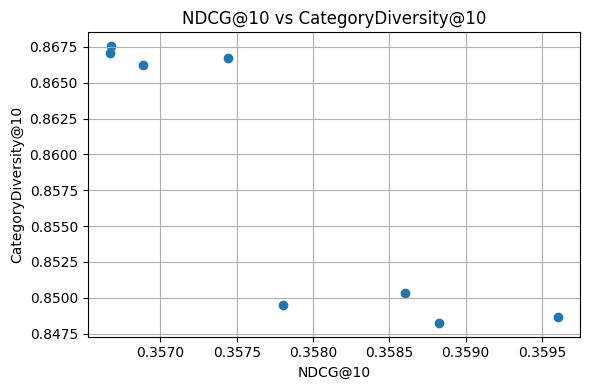

Guardado en: /content/drive/MyDrive/Proyecto/tradeoff_ndcg_diversity.png


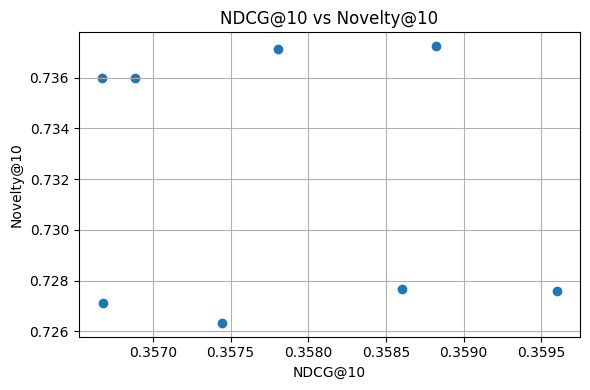

Guardado en: /content/drive/MyDrive/Proyecto/tradeoff_ndcg_novelty.png


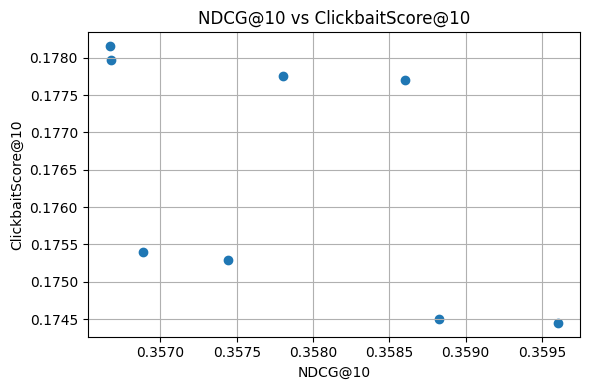

Guardado en: /content/drive/MyDrive/Proyecto/tradeoff_ndcg_clickbait.png


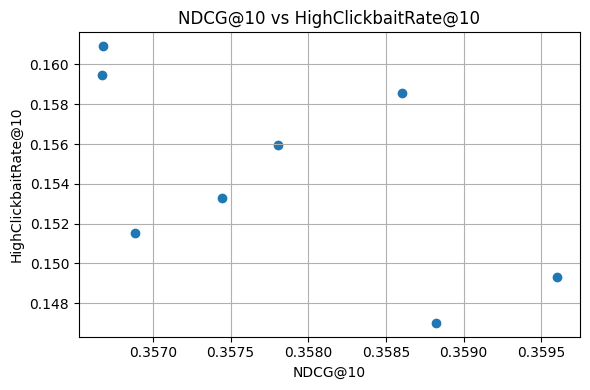

Guardado en: /content/drive/MyDrive/Proyecto/tradeoff_ndcg_highclickbait.png


In [ ]:
plot_tradeoff(
    grid_results_df,
    "NDCG@10",
    "CategoryDiversity@10",
    "tradeoff_ndcg_diversity.png"
)

plot_tradeoff(
    grid_results_df,
    "NDCG@10",
    "Novelty@10",
    "tradeoff_ndcg_novelty.png"
)

plot_tradeoff(
    grid_results_df,
    "NDCG@10",
    "ClickbaitScore@10",
    "tradeoff_ndcg_clickbait.png"
)

plot_tradeoff(
    grid_results_df,
    "NDCG@10",
    "HighClickbaitRate@10",
    "tradeoff_ndcg_highclickbait.png"
)


# Guardamos resultado

In [ ]:
grid_output_path = PROJECT_DIR / "reranking_grid_search_results.csv"
grid_results_df.to_csv(grid_output_path, index=False)

balanced_output_path = PROJECT_DIR / "reranking_grid_search_balanced.csv"
best_balanced.to_csv(balanced_output_path, index=False)

print("Resultados grid search guardados en:", grid_output_path)
print("Resultados balanceados guardados en:", balanced_output_path)

Resultados grid search guardados en: /content/drive/MyDrive/Proyecto/reranking_grid_search_results.csv
Resultados balanceados guardados en: /content/drive/MyDrive/Proyecto/reranking_grid_search_balanced.csv


#Comparar el mejor modelo balanceado contra los modelos anteriores

In [ ]:
best_row = best_balanced.iloc[0]

best_lambda = best_row["lambda_clickbait"]
best_gamma = best_row["gamma_novelty"]
best_delta = best_row["delta_category"]

ranking_best = add_weighted_score(
    ranking_df,
    lambda_clickbait=best_lambda,
    gamma_novelty=best_gamma
)

ranking_best = (
    ranking_best
    .groupby("impression_id", group_keys=False)
    .apply(
        diversity_rerank_group_weighted,
        base_score_col="score_weighted",
        delta_category=best_delta
    )
)

ranking_best[[
    "impression_id",
    "news_id",
    "title",
    "category",
    "label",
    "score_tfidf_only",
    "score_rerank_weighted",
    "clickbait_score",
    "novelty_score_norm",
    "high_clickbait_synthetic"
]].head()

print("Mejores pesos encontrados:")
print("lambda_clickbait:", best_lambda)
print("gamma_novelty:", best_gamma)
print("delta_category:", best_delta)


Mejores pesos encontrados:
lambda_clickbait: 0.1
gamma_novelty: 0.05
delta_category: 0.05


/tmp/ipykernel_26829/165893792.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
def get_top10_example(df, impression_id, score_col):
    """
    Devuelve el top-10 de una impresión específica según el score indicado.
    """
    return (
        df[df["impression_id"] == impression_id]
        .sort_values(score_col, ascending=False)
        .head(10)[[
            "impression_id",
            "news_id",
            "title",
            "category",
            "label",
            "clickbait_score",
            "novelty_score_norm",
            "high_clickbait_synthetic"
        ]]
    )


In [ ]:
example_rows = []

for impression_id, group_base in ranking_df.groupby("impression_id"):
    group_best = ranking_best[ranking_best["impression_id"] == impression_id]

    # Top-10 del modelo TF-IDF base
    top_base = group_base.sort_values("score_tfidf_only", ascending=False).head(10)

    # Top-10 del modelo re-ranking optimizado
    top_best = group_best.sort_values("score_rerank_weighted", ascending=False).head(10)

    # Métricas simples para comparar ambas listas
    base_div = top_base["category"].nunique()
    best_div = top_best["category"].nunique()

    base_highclickbait = top_base["high_clickbait_synthetic"].mean()
    best_highclickbait = top_best["high_clickbait_synthetic"].mean()

    base_clickbait = top_base["clickbait_score"].mean()
    best_clickbait = top_best["clickbait_score"].mean()

    example_rows.append({
        "impression_id": impression_id,
        "base_diversity": base_div,
        "rerank_diversity": best_div,
        "base_highclickbait": base_highclickbait,
        "rerank_highclickbait": best_highclickbait,
        "base_clickbait": base_clickbait,
        "rerank_clickbait": best_clickbait,
        "diversity_gain": best_div - base_div,
        "highclickbait_reduction": base_highclickbait - best_highclickbait,
        "clickbait_reduction": base_clickbait - best_clickbait
    })

examples_df = pd.DataFrame(example_rows)

examples_df.sort_values(
    ["diversity_gain", "highclickbait_reduction", "clickbait_reduction"],
    ascending=False
).head(10)


In [ ]:
selected_impression = examples_df.sort_values(
    ["diversity_gain", "highclickbait_reduction", "clickbait_reduction"],
    ascending=False
).iloc[0]["impression_id"]

selected_impression


In [ ]:
top10_tfidf_example = get_top10_example(
    ranking_df,
    selected_impression,
    "score_tfidf_only"
)

top10_tfidf_example

In [ ]:
top10_rerank_example = get_top10_example(
    ranking_best,
    selected_impression,
    "score_rerank_weighted"
)

top10_rerank_example

In [ ]:
top10_tfidf_example.to_csv(
    PROJECT_DIR / "example_top10_tfidf.csv",
    index=False
)

top10_rerank_example.to_csv(
    PROJECT_DIR / "example_top10_rerank.csv",
    index=False
)

examples_df.to_csv(
    PROJECT_DIR / "recommendation_examples_summary.csv",
    index=False
)

In [ ]:
best_model_metrics = best_row[[
    "AUC",
    "MRR@10",
    "NDCG@10",
    "CategoryCoverage@10",
    "CategoryDiversity@10",
    "Novelty@10",
    "ClickbaitScore@10",
    "HighClickbaitRate@10"
]].to_dict()

best_model_metrics["model"] = "Re-ranking optimizado"

comparison_df = pd.concat([
    results_df,
    pd.DataFrame([best_model_metrics])
], ignore_index=True)

comparison_df = comparison_df[
    ["model"] + [col for col in comparison_df.columns if col != "model"]
]


final_results_path = PROJECT_DIR / "final_reranking_comparison.csv"

comparison_df.to_csv(final_results_path, index=False)

print("Tabla final guardada en:", final_results_path)

comparison_df


Tabla final guardada en: /content/drive/MyDrive/Proyecto/final_reranking_comparison.csv


,model,AUC,MRR@10,NDCG@10,CategoryCoverage@10,CategoryDiversity@10,Novelty@10,ClickbaitScore@10,HighClickbaitRate@10
0,Random,0.498667,0.227532,0.286858,5.8646,0.875441,0.728455,0.180448,0.184976
1,Most Popular,0.497540,0.225949,0.287941,5.9806,0.885298,0.505433,0.188002,0.248936
2,TF-IDF base,0.580933,0.309069,0.362479,5.3120,0.828712,0.718160,0.182331,0.171596
3,TF-IDF + low clickbait,0.586844,0.309470,0.362736,5.2762,0.825698,0.721833,0.173222,0.146336
4,TF-IDF + novelty,0.578257,0.306160,0.358638,5.2962,0.826756,0.739397,0.181954,0.164256
5,TF-IDF + low clickbait + novelty,0.585935,0.309567,0.362321,5.2676,0.824512,0.737987,0.173303,0.143376
6,Re-ranking completo,0.573185,0.304285,0.355068,6.4160,0.881592,0.735391,0.175763,0.154096
7,Re-ranking optimizado,0.579404,0.307145,0.358824,5.7522,0.848250,0.737240,0.174495,0.147016
